# Telco Customer Churn Prediction

## İş Problemi

Şirketi terk edecek müşterileri tahmin edebilecek bir makine öğrenmesi modeli geliştirilmesi beklenmektedir. Modeli geliştirmeden önce gerekli olan **veri analizi** ve **özellik mühendisliği (feature engineering)** adımlarının gerçekleştirilmesi gerekmektedir.

## Veri Seti Hikayesi

Telco müşteri kaybı verileri, üçüncü çeyrekte Kaliforniya'daki 7043 müşteriye ev telefonu ve İnternet hizmetleri sağlayan hayali bir telekom şirketi hakkında bilgi içerir. Hangi müşterilerin hizmetlerinden ayrıldığını, kaldığını veya hizmete kaydolduğunu gösterir.

**21 Değişken, 7043 Gözlem, 977.5 KB**

### Değişkenler

| Değişken | Açıklama |
|---|---|
| CustomerId | Müşteri İd'si |
| Gender | Cinsiyet |
| SeniorCitizen | Müşterinin yaşlı olup olmadığı (1, 0) |
| Partner | Müşterinin bir ortağı olup olmadığı (Evet, Hayır) |
| Dependents | Müşterinin bakmakla yükümlü olduğu kişiler olup olmadığı (Evet, Hayır) |
| tenure | Müşterinin şirkette kaldığı ay sayısı |
| PhoneService | Müşterinin telefon hizmeti olup olmadığı (Evet, Hayır) |
| MultipleLines | Müşterinin birden fazla hattı olup olmadığı (Evet, Hayır, Telefon hizmeti yok) |
| InternetService | Müşterinin internet servis sağlayıcısı (DSL, Fiber optik, Hayır) |
| OnlineSecurity | Müşterinin çevrimiçi güvenliğinin olup olmadığı (Evet, Hayır, İnternet hizmeti yok) |
| OnlineBackup | Müşterinin online yedeğinin olup olmadığı (Evet, Hayır, İnternet hizmeti yok) |
| DeviceProtection | Müşterinin cihaz korumasına sahip olup olmadığı (Evet, Hayır, İnternet hizmeti yok) |
| TechSupport | Müşterinin teknik destek alıp almadığı (Evet, Hayır, İnternet hizmeti yok) |
| StreamingTV | Müşterinin TV yayını olup olmadığı (Evet, Hayır, İnternet hizmeti yok) |
| StreamingMovies | Müşterinin film akışı olup olmadığı (Evet, Hayır, İnternet hizmeti yok) |
| Contract | Müşterinin sözleşme süresi (Aydan aya, Bir yıl, İki yıl) |
| PaperlessBilling | Müşterinin kağıtsız faturası olup olmadığı (Evet, Hayır) |
| PaymentMethod | Müşterinin ödeme yöntemi (Elektronik çek, Posta çeki, Banka havalesi (otomatik), Kredi kartı (otomatik)) |
| MonthlyCharges | Müşteriden aylık olarak tahsil edilen tutar |
| TotalCharges | Müşteriden tahsil edilen toplam tutar |
| Churn | Müşterinin hizmeti terk edip etmediği - churn olup olmadığı (Evet veya Hayır) |

## Proje Görevleri

- **Görev 1:** Keşifçi Veri Analizi (EDA)
- **Görev 2:** Feature Engineering
- **Görev 3:** Modelleme

In [ ]:
# Sayısal işlemler için NumPy
import numpy as np

# Tablo (DataFrame) işlemleri için Pandas
import pandas as pd

# Görselleştirme kütüphaneleri
import seaborn as sns
from matplotlib import pyplot as plt

# Veri ön işleme: kategorik değişkenleri sayısala çevirme ve ölçeklendirme (scaling) için
from sklearn.preprocessing import LabelEncoder, RobustScaler

# Modelleme, çapraz doğrulama (cross validation) ve hiperparametre optimizasyonu için
from sklearn.model_selection import cross_validate, GridSearchCV

# Görev 3'te karşılaştırılacak sınıflandırma (classification) algoritmaları
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Uyarı mesajlarını (warning) bastırmak için (çıktıyı sadeleştirir, hataları saklamaz)
import warnings
warnings.filterwarnings("ignore")

# --- Pandas görüntüleme ayarları ---
pd.set_option('display.max_columns', None)   # Tüm sütunlar gösterilsin
pd.set_option('display.width', 500)          # Satırlar yan yana daha rahat görünsün
pd.set_option('display.max_rows', None)      # Tüm satırlar gösterilsin

# NOT: pandas 3.0 ile birlikte metinsel (string) sütunlar varsayılan olarak "object" yerine
# yeni "str" (StringDtype) tipiyle okunuyor. Bu notebook'ta kullanacağımız birçok fonksiyon
# (grab_col_names, one_hot_encoder vb.) klasik "object" (dtype == 'O') kontrolüne dayanıyor.
# Bu satır, eski/klasik davranışı geri getirerek metinsel sütunların yine "object" tipinde
# okunmasını sağlar ve fonksiyonların hatasız çalışmasını garanti eder.
pd.set_option("future.infer_string", False)

# Veri setinin okunması
df = pd.read_csv("datasets/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Görev 1: Keşifçi Veri Analizi (EDA)

### Adım 1: Numerik ve kategorik değişkenleri yakalayınız.

In [ ]:
def check_df(dataframe, head=5):
    """
    Veri setinin genel resmini (shape, tip, ilk/son gözlemler, eksik değer, betimsel istatistik)
    tek bir fonksiyon çağrısıyla ekrana yazdırır. Herhangi bir yeni veri setine ilk bakışta
    kullanılacak standart bir "keşif" fonksiyonudur.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        İncelenecek veri seti.
    head : int, opsiyonel
        head()/tail() ile gösterilecek satır sayısı (varsayılan: 5).
    """
    print("##################### Shape #####################")
    print(dataframe.shape)  # satır ve sütun sayısı
    print("##################### Types #####################")
    print(dataframe.dtypes)  # her değişkenin veri tipi
    print("##################### Head #####################")
    print(dataframe.head(head))  # ilk "head" satır
    print("##################### Tail #####################")
    print(dataframe.tail(head))  # son "head" satır
    print("##################### NA #####################")
    print(dataframe.isnull().sum())  # değişken başına eksik (NaN) değer sayısı
    print("##################### Quantiles #####################")
    # Sadece sayısal (numeric) sütunlar için çeyreklik/özet istatistikleri
    print(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T)


check_df(df)

##################### Shape #####################
(7043, 21)
##################### Types #####################
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
##################### Head #####################
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling          

In [ ]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Bir veri setindeki sütunları türlerine göre kategorize etmek, veriyi anlamak ve modelleme
    sürecinde doğru şekilde kullanmak için önemlidir. Bu fonksiyon, verilen bir pandas DataFrame'deki
    değişkenleri (sütunları) üç ana grupta toplar:
        1. Kategorik değişkenler (cat_cols)
        2. Numerik değişkenler (num_cols)
        3. Kategorik görünümlü ama çok fazla benzersiz değer içeren (kardinal) değişkenler (cat_but_car)

    Adım adım mantık:
        1. Kategorik değişkenler genellikle yazısal (object tipinde) olur. Ancak bazen, içerisinde
           az sayıda benzersiz değer olan sayısal tipteki sütunlar da aslında kategoriktir
           (örn. SeniorCitizen: 0/1 gibi 2 değer alan bir sayısal sütun).
        2. Numerik değişkenler sayısal değerler içerir (int veya float tipinde).
        3. Kategorik görünümlü kardinal değişkenler ise yazısal olup çok fazla benzersiz değer
           içerir (örn. customerID). Bunları ayrı ele almak gerekir, çünkü bu tip sütunların
           doğrudan modelde kullanılması uygun değildir (bilgi taşımaz, sadece kimlik bilgisidir).

    Parametreler
    ----------
    dataframe : pd.DataFrame
        Analiz edilecek veri seti.
    cat_th : int
        Sayısal olup az sayıda benzersiz kategoriye sahip sütunların kategorik kabul edilmesi
        için eşik değeri. Varsayılan: 10.
    car_th : int
        Kategorik olup çok fazla benzersiz değere sahip sütunların (kardinallerin) belirlenmesi
        için eşik değeri. Varsayılan: 20.

    Dönüş
    ------
    cat_cols : list
        Kategorik sütun isimleri.
    num_cols : list
        Numerik sütun isimleri.
    cat_but_car : list
        Kategorik görünüp çok fazla benzersiz değer içeren sütun isimleri.

    Uyarı
    -----
    cat_cols + num_cols + cat_but_car toplamı, toplam sütun sayısını verir.
    """

    # 1. Kategorik sütunların isimlerini bul ("object" tipinde olanlar)
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]

    # 2. Numerik görünümlü olup aslında kategorik olan sütunları belirle ("num_but_cat")
    # Veri tipi sayısal olup eşsiz değer sayısı cat_th'den azsa, bunlar da kategori sayılır
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "O"]

    # 3. Yazısal tipte olup çok fazla eşsiz değeri olan sütunlar ("cat_but_car": kategorik görünümlü kardinal)
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]

    # 4. Kategorik sütunlar listesine, numerik tipte olup az kategoriye sahip sütunları ekle
    cat_cols = cat_cols + num_but_cat

    # Kategorik görünümlü kardinal (çok değerli) olanları kategoriklerden çıkar
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # 5. Numerik sütunların isimlerini bul (tip olarak numerik olanlar)
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]

    # Numerik olup az kategoriye sahip olanlar zaten kategoriklere eklendiği için burada hariç tut
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # Sonucu ekrana yaz (kontrol amaçlı)
    print(f"Observations (gözlem/satır sayısı): {dataframe.shape[0]}")
    print(f"Variables (değişken/sütun sayısı): {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations (gözlem/satır sayısı): 7043
Variables (değişken/sütun sayısı): 21
cat_cols: 17
num_cols: 2
cat_but_car: 2
num_but_cat: 1


In [ ]:
# Kategorik değişkenler: SeniorCitizen (0/1, numerik ama az kategorili olduğu için kategorik
# sayıldı) dahil olmak üzere, "Evet/Hayır" ve benzeri sınıflı tüm sütunlar.
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

In [ ]:
# Numerik değişkenler: tenure ve MonthlyCharges gerçekten sayısal.
# TotalCharges'ın burada görünmediğine dikkat! Çünkü CSV'de bazı satırlarda boşluk (" ")
# karakteri olduğu için pandas bu sütunu yanlışlıkla "object" (metin) olarak okumuş durumda.
# Bu tip hatasını bir sonraki adımda düzelteceğiz.
num_cols

['tenure', 'MonthlyCharges']

In [ ]:
# Kategorik görünümlü kardinal değişken: customerID her müşteride farklı bir değer aldığı için
# (7043 benzersiz değer) bilgi taşımaz; modelleme aşamasında veri setinden çıkarılacaktır.
cat_but_car

['customerID', 'TotalCharges']

### Adım 2: Gerekli düzenlemeleri yapınız. (Tip hatası olan değişkenler gibi)

In [ ]:
# 1) TotalCharges tip hatası: sütun aslında sayısal olmalı, ancak bazı satırlarda
#    boşluk (" ") karakteri bulunduğu için pandas onu "object" (metin) olarak okumuştu.
#    pd.to_numeric ile sayısala çeviriyoruz; çevrilemeyen (boşluk gibi) değerler
#    "errors='coerce'" sayesinde otomatik olarak NaN'a dönüştürülür.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# 2) Hedef değişken (target) olan Churn, "Yes"/"No" metinleriyle tutuluyor.
#    Modelleme ve istatistiksel analizler (groupby ile ortalama alma vb.) için
#    bu değişkeni 1 (churn oldu) / 0 (churn olmadı) şeklinde sayısala çeviriyoruz.
df["Churn"] = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

# Tip düzeltmelerinden sonra numerik/kategorik değişkenleri tekrar yakalıyoruz.
# Artık TotalCharges "num_cols" içine, Churn ise (sadece 2 farklı değer aldığı için) "cat_cols" içine düşecek.
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations (gözlem/satır sayısı): 7043
Variables (değişken/sütun sayısı): 21
cat_cols: 17
num_cols: 3
cat_but_car: 1
num_but_cat: 2


### Adım 3: Numerik ve kategorik değişkenlerin veri içindeki dağılımını gözlemleyiniz.

        gender     Ratio
gender                  
Male      3555  50.47565
Female    3488  49.52435
##########################################


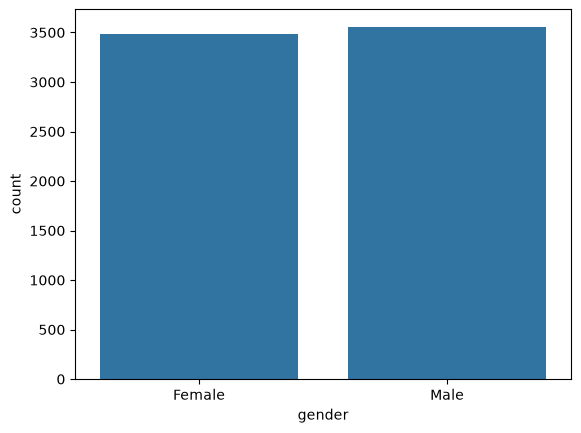

         Partner     Ratio
Partner                   
No          3641  51.69672
Yes         3402  48.30328
##########################################


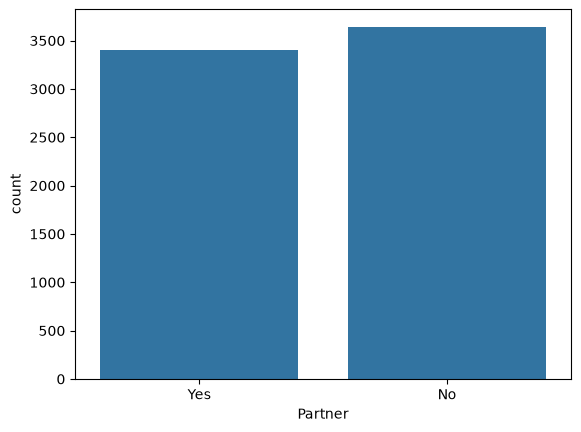

            Dependents      Ratio
Dependents                       
No                4933  70.041176
Yes               2110  29.958824
##########################################


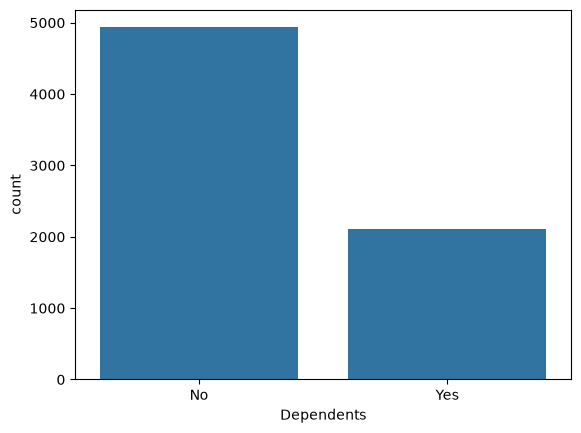

              PhoneService      Ratio
PhoneService                         
Yes                   6361  90.316626
No                     682   9.683374
##########################################


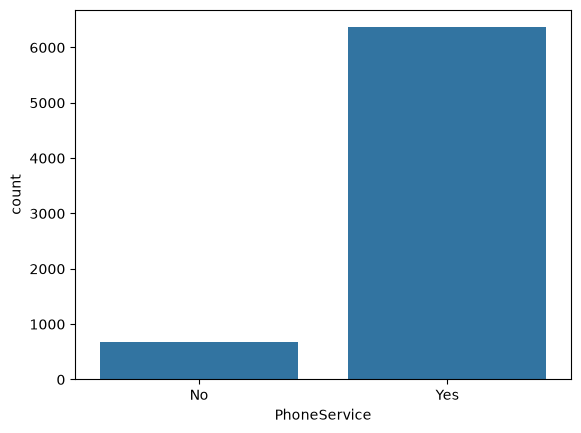

                  MultipleLines      Ratio
MultipleLines                             
No                         3390  48.132898
Yes                        2971  42.183729
No phone service            682   9.683374
##########################################


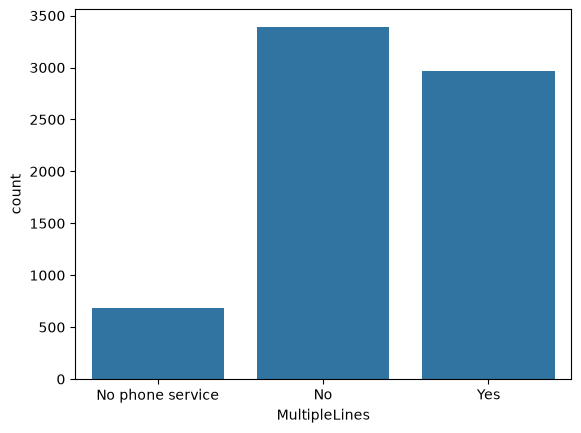

                 InternetService      Ratio
InternetService                            
Fiber optic                 3096  43.958540
DSL                         2421  34.374556
No                          1526  21.666903
##########################################


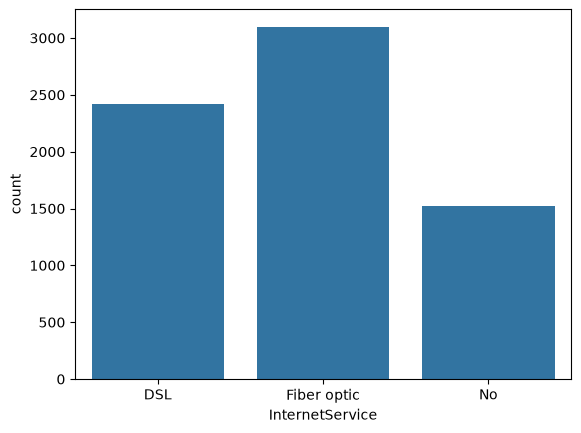

                     OnlineSecurity      Ratio
OnlineSecurity                                
No                             3498  49.666335
Yes                            2019  28.666761
No internet service            1526  21.666903
##########################################


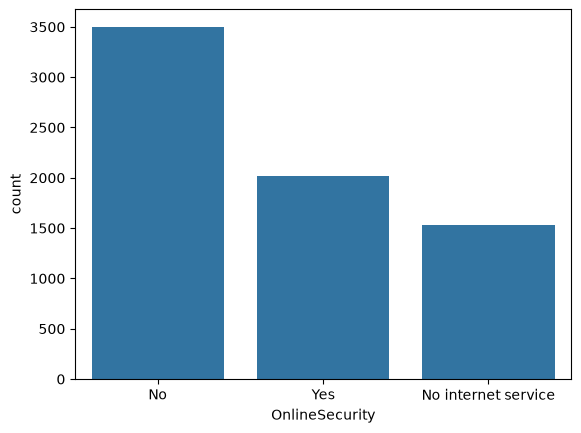

                     OnlineBackup      Ratio
OnlineBackup                                
No                           3088  43.844952
Yes                          2429  34.488144
No internet service          1526  21.666903
##########################################


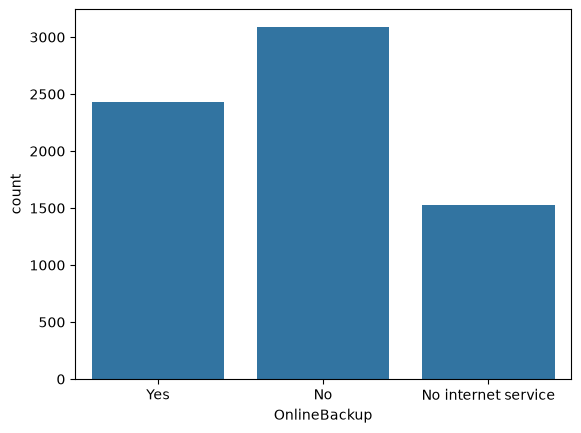

                     DeviceProtection      Ratio
DeviceProtection                                
No                               3095  43.944342
Yes                              2422  34.388755
No internet service              1526  21.666903
##########################################


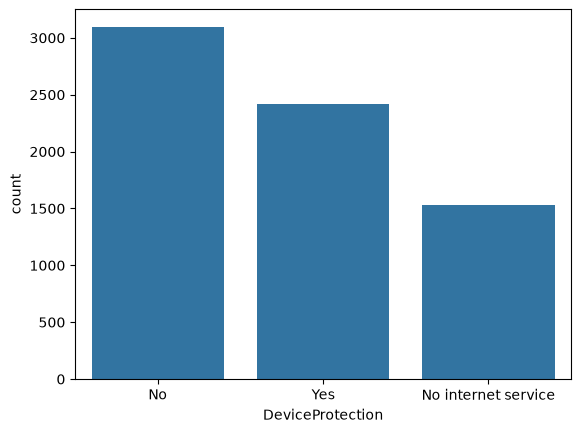

                     TechSupport      Ratio
TechSupport                                
No                          3473  49.311373
Yes                         2044  29.021724
No internet service         1526  21.666903
##########################################


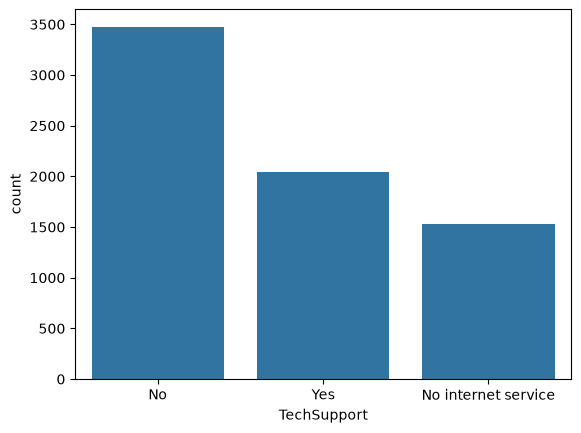

                     StreamingTV      Ratio
StreamingTV                                
No                          2810  39.897771
Yes                         2707  38.435326
No internet service         1526  21.666903
##########################################


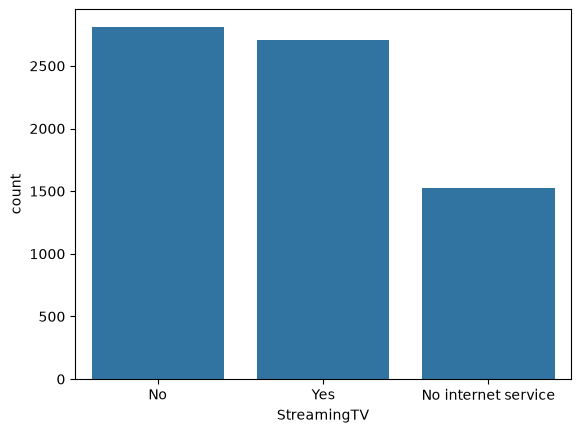

                     StreamingMovies      Ratio
StreamingMovies                                
No                              2785  39.542808
Yes                             2732  38.790288
No internet service             1526  21.666903
##########################################


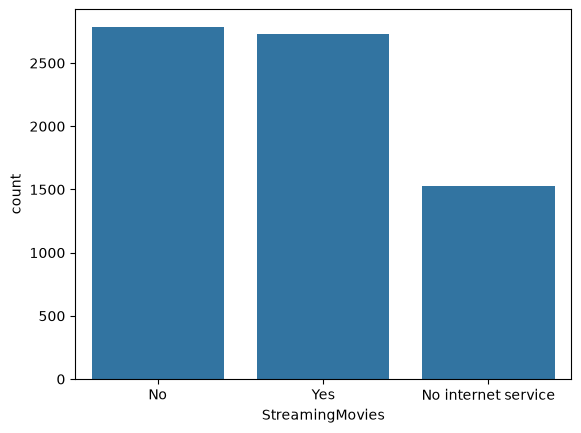

                Contract      Ratio
Contract                           
Month-to-month      3875  55.019168
Two year            1695  24.066449
One year            1473  20.914383
##########################################


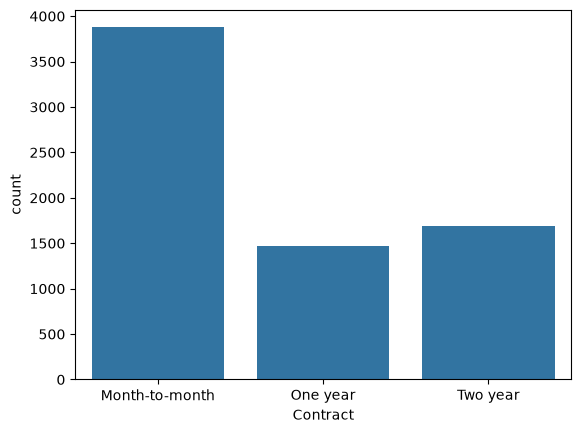

                  PaperlessBilling      Ratio
PaperlessBilling                             
Yes                           4171  59.221922
No                            2872  40.778078
##########################################


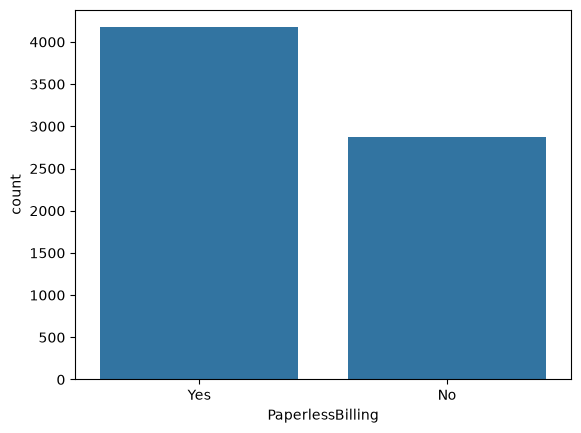

                           PaymentMethod      Ratio
PaymentMethod                                      
Electronic check                    2365  33.579441
Mailed check                        1612  22.887974
Bank transfer (automatic)           1544  21.922476
Credit card (automatic)             1522  21.610109
##########################################


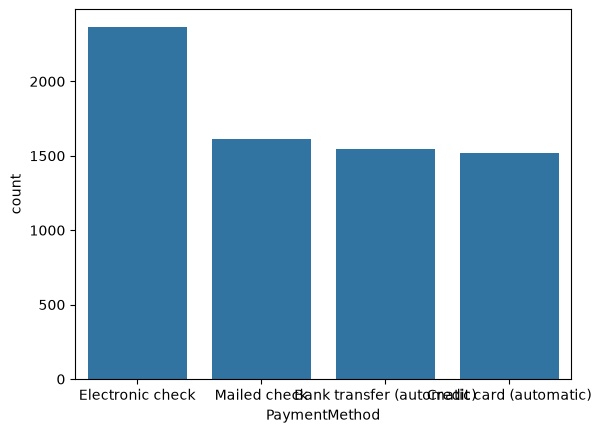

               SeniorCitizen      Ratio
SeniorCitizen                          
0                       5901  83.785319
1                       1142  16.214681
##########################################


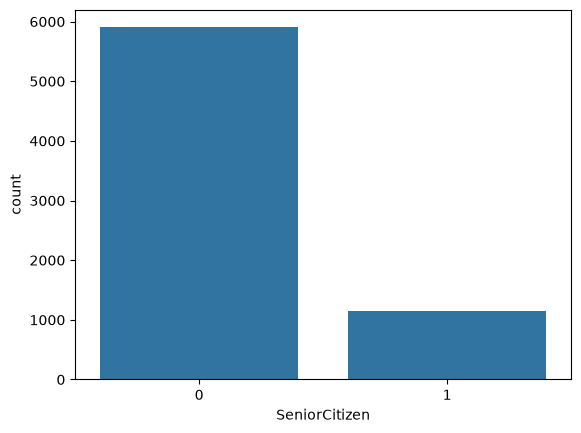

       Churn      Ratio
Churn                  
0       5174  73.463013
1       1869  26.536987
##########################################


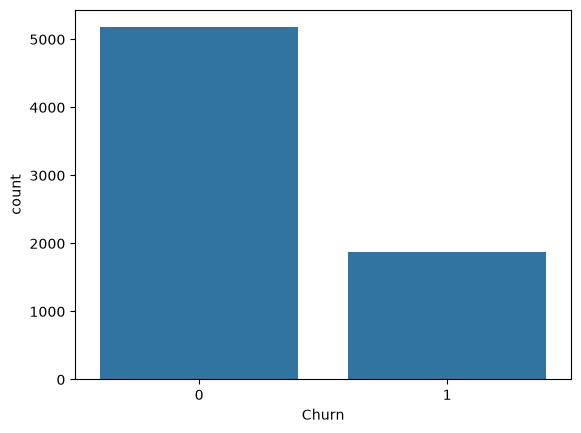

In [ ]:
def cat_summary(dataframe, col_name, plot=False):
    """
    Belirtilen kategorik sütunun hem frekans (adet) hem de oran (yüzde) dağılımını
    gösteren bir özet tablo oluşturur ve yazdırır. plot=True verilirse, seaborn.countplot
    ile ilgili değişkenin dağılımını görselleştiren bir grafik de çizer.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        Analiz yapılacak veri seti.
    col_name : str
        Özetlenmesi istenen kategorik sütunun adı.
    plot : bool, opsiyonel
        True verilirse sütunun dağılımını görselleştirir (varsayılan: False).
    """
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                         "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")

    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show(block=True)


# Tüm kategorik değişkenler (hedef değişken Churn dahil) için dağılımı inceliyoruz.
for col in cat_cols:
    cat_summary(df, col, plot=True)

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
5%          1.000000
10%         2.000000
20%         6.000000
30%        12.000000
40%        20.000000
50%        29.000000
60%        40.000000
70%        50.000000
80%        60.000000
90%        69.000000
95%        72.000000
99%        72.000000
max        72.000000
Name: tenure, dtype: float64


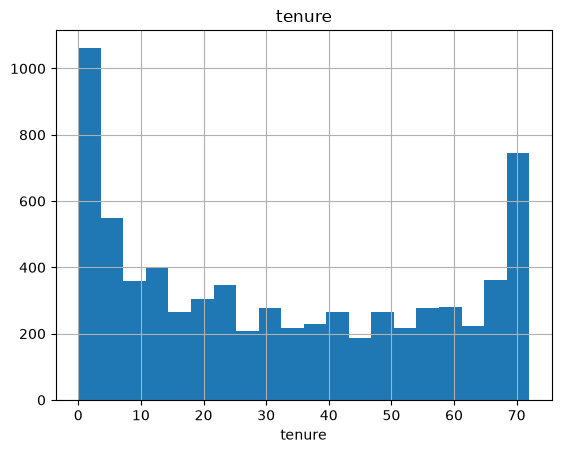

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
5%         19.650000
10%        20.050000
20%        25.050000
30%        45.850000
40%        58.830000
50%        70.350000
60%        79.100000
70%        85.500000
80%        94.250000
90%       102.600000
95%       107.400000
99%       114.729000
max       118.750000
Name: MonthlyCharges, dtype: float64


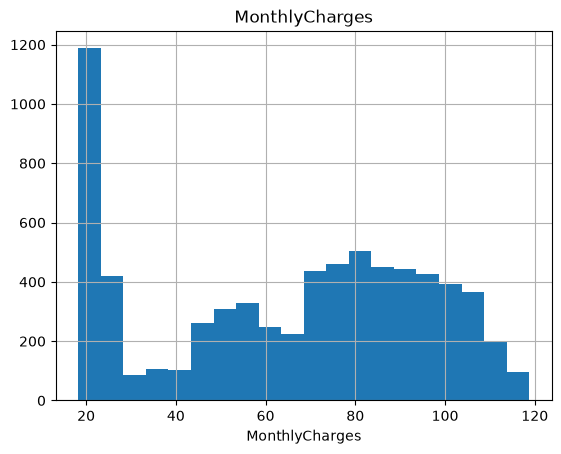

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
5%         49.605000
10%        84.600000
20%       267.070000
30%       551.995000
40%       944.170000
50%      1397.475000
60%      2048.950000
70%      3141.130000
80%      4475.410000
90%      5976.640000
95%      6923.590000
99%      8039.883000
max      8684.800000
Name: TotalCharges, dtype: float64


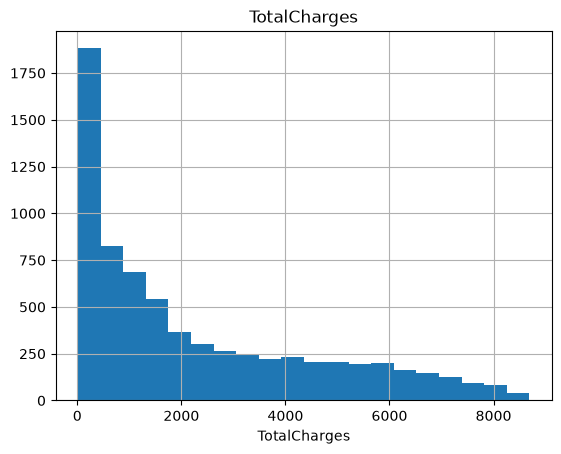

In [ ]:
def num_summary(dataframe, numerical_col, plot=False):
    """
    Verilen sayısal değişkenin temel istatistiksel özetini ve yüzdelik (quantile)
    değerlerini gösterir. plot=True olarak ayarlanırsa, ilgili değişkenin
    histogramını çizer.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        Analizi yapılacak veri seti.
    numerical_col : str
        Temel istatistiklerin hesaplanacağı sayısal değişken ismi.
    plot : bool, opsiyonel
        True verilirse değişkenin histogramı çizilir (varsayılan: False).
    """
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)


for col in num_cols:
    num_summary(df, col, plot=True)

### Adım 4: Kategorik değişkenler ile hedef değişken incelemesini yapınız.

In [ ]:
def target_summary_with_cat(dataframe, target, categorical_col):
    """
    Belirli bir kategorik değişkenin (categorical_col) her bir kategorisi için,
    hedef değişkenin (target) ortalamasını hesaplar ve ekrana bastırır.

    Örneğin; Contract (sözleşme tipi) değişkeninin her bir sınıfı (Aydan aya, Bir yıl, İki yıl)
    için Churn oranının (ortalamasının) ne olduğunu gösterir. Bu sayede, hangi müşteri
    profillerinin churn olmaya daha yatkın olduğunu anlayabiliriz.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        İşlem yapılacak veri seti.
    target : str
        Hedef değişkenin ismi (örn. "Churn").
    categorical_col : str
        İncelenecek kategorik değişkenin ismi.
    """
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()}), end="\n\n\n")


# Churn hedef değişkeninin kendisi hariç, diğer tüm kategorik değişkenler için churn oranını inceliyoruz.
for col in cat_cols:
    if col != "Churn":
        target_summary_with_cat(df, "Churn", col)

        TARGET_MEAN
gender             
Female     0.269209
Male       0.261603


         TARGET_MEAN
Partner             
No          0.329580
Yes         0.196649


            TARGET_MEAN
Dependents             
No             0.312791
Yes            0.154502


              TARGET_MEAN
PhoneService             
No               0.249267
Yes              0.267096


                  TARGET_MEAN
MultipleLines                
No                   0.250442
No phone service     0.249267
Yes                  0.286099


                 TARGET_MEAN
InternetService             
DSL                 0.189591
Fiber optic         0.418928
No                  0.074050


                     TARGET_MEAN
OnlineSecurity                  
No                      0.417667
No internet service     0.074050
Yes                     0.146112


                     TARGET_MEAN
OnlineBackup                    
No                      0.399288
No internet service     0.074050
Yes                     0.2153

In [ ]:
def target_summary_with_num(dataframe, target, numerical_col):
    """
    Belirli bir sayısal değişkenin (numerical_col), hedef değişkenin (target) her bir
    kategorisi (0 / 1) için ortalamasını hesaplar ve ekrana bastırır.

    Örneğin; churn olan (1) ve olmayan (0) müşterilerin ortalama "tenure" (şirkette kalma süresi)
    değerlerini karşılaştırarak, churn olan müşterilerin genelde daha yeni müşteriler olup
    olmadığını görebiliriz.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        Analiz yapılacak veri seti.
    target : str
        Hedef değişkenin adı (örn. "Churn").
    numerical_col : str
        Ortalama değeri incelenecek sayısal değişkenin adı.
    """
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")


for col in num_cols:
    target_summary_with_num(df, "Churn", col)

          tenure
Churn           
0      37.569965
1      17.979133


       MonthlyCharges
Churn                
0           61.265124
1           74.441332


       TotalCharges
Churn              
0       2555.344141
1       1531.796094




### Adım 5: Aykırı gözlem var mı inceleyiniz.

In [ ]:
def outlier_thresholds(dataframe, col_name, q1=0.25, q3=0.75):
    """
    Verilen bir değişken için aykırı değer sınırlarını (alt ve üst limit) hesaplar.
    Sınırlar, çeyreklikler ve IQR (Interquartile Range - çeyrekler arası mesafe)
    kullanılarak belirlenir:
        IQR = Q3 - Q1
        Alt limit = Q1 - 1.5 * IQR
        Üst limit = Q3 + 1.5 * IQR

    Parametreler
    ----------
    dataframe : pd.DataFrame
        İşlem yapılacak veri çerçevesi.
    col_name : str
        Sınırları hesaplanacak değişkenin ismi.
    q1, q3 : float
        Alt ve üst çeyreklik değerleri (varsayılan: 0.25 ve 0.75).

    Dönüş
    ------
    tuple : (alt limit, üst limit)
    """
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    low_limit = quartile1 - 1.5 * interquantile_range
    up_limit = quartile3 + 1.5 * interquantile_range
    return low_limit, up_limit


def check_outlier(dataframe, col_name):
    """
    Verilen değişkende (col_name), IQR yöntemiyle hesaplanan sınırların dışında
    kalan en az bir aykırı (outlier) gözlem olup olmadığını kontrol eder.

    Dönüş
    ------
    bool : Aykırı değer varsa True, yoksa False.
    """
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    outliers = dataframe[(dataframe[col_name] < low_limit) | (dataframe[col_name] > up_limit)]
    return outliers.shape[0] > 0


# Sayısal değişkenlerin her biri için aykırı gözlem kontrolü yapıyoruz.
for col in num_cols:
    print(col, check_outlier(df, col))

# Sonuç: Telco veri setindeki sayısal değişkenlerde (tenure, MonthlyCharges, TotalCharges)
# klasik IQR (1.5 katsayılı) yöntemine göre aykırı gözlem bulunmamaktadır.
# Bu nedenle bir sonraki (Feature Engineering) bölümünde aykırı değer baskılama
# (replace_with_thresholds) işlemine gerek kalmayacaktır; ancak fonksiyonu ileride
# kullanabilmek için tanımlı tutuyoruz.

tenure False
MonthlyCharges False
TotalCharges False


### Adım 6: Eksik gözlem var mı inceleyiniz.

In [ ]:
def missing_values_table(dataframe, na_name=False):
    """
    Veri setindeki eksik (NaN) değerleri analiz eder ve özet bir tablo halinde gösterir.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        İncelenecek veri seti.
    na_name : bool, opsiyonel
        True verilirse, eksik değere sahip kolon isimlerinin listesini döndürür.

    Dönüş
    ------
    list veya None : na_name=True ise eksik değerli kolon isimleri, aksi halde None.
    """
    # Eksik değere sahip kolonları bulma
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    # Eksik değer sayısı (n_miss) ve toplam içindeki oranı (ratio) hesaplama
    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)

    # Sonuçları tek bir tabloda birleştirme
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns


missing_values_table(df)

# Sonuç: Sadece TotalCharges sütununda 11 eksik gözlem bulunmaktadır (%0.16).
# Bu eksik gözlemler, aslında CSV dosyasındaki boşluk (" ") karakterlerinin
# pd.to_numeric(..., errors="coerce") ile NaN'a çevrilmesinden kaynaklanmaktadır.

              n_miss  ratio
TotalCharges      11   0.16


# Görev 2: Feature Engineering

### Adım 1: Eksik ve aykırı gözlemler için gerekli işlemleri yapınız.

In [ ]:
# --- Eksik Gözlemler ---

# Önce, TotalCharges'ı eksik olan müşterilerin "tenure" (kaç aydır müşteri olduğu) bilgisine bakalım.
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [ ]:
# Gördüğümüz gibi, TotalCharges'ı eksik olan tüm gözlemlerin tenure (kalış süresi) değeri 0.
# Yani bu müşteriler henüz ilk faturalarını almamış, tamamen yeni kaydolmuş müşteriler.
# Bu nedenle, eksik TotalCharges değerlerini "henüz hiç ücret tahsil edilmedi" mantığıyla
# 0 ile dolduruyoruz (ortalama veya medyan ile doldurmak burada anlamlı olmaz, çünkü bu
# müşterilerin gerçek toplam harcaması fiilen 0'dır).
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Kontrol: artık hiç eksik gözlem kalmamalı.
missing_values_table(df)

Empty DataFrame
Columns: [n_miss, ratio]
Index: []


In [ ]:
# --- Aykırı Gözlemler ---

def replace_with_thresholds(dataframe, variable):
    """
    Belirtilen değişkendeki aykırı (outlier) değerleri, IQR yöntemiyle hesaplanan alt ve
    üst eşik değerleriyle değiştirir (baskılar). Bu işleme "winsorization" da denir;
    veri kaybetmeden aykırı değerlerin etkisini sınırlandırmayı sağlar.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        İşlem yapılacak veri çerçevesi.
    variable : str
        Aykırı değerleri baskılanacak değişkenin ismi.
    """
    low_limit, up_limit = outlier_thresholds(dataframe, variable)

    # Sütun tam sayı (integer) tipindeyse, eşik değerleri ondalıklı (float) olabileceği
    # için önce sütunu float'a çeviriyoruz.
    if pd.api.types.is_integer_dtype(dataframe[variable]):
        dataframe[variable] = dataframe[variable].astype(float)

    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit


# Adım 5'te (EDA) gördüğümüz üzere, sayısal değişkenlerin hiçbirinde IQR yöntemine göre
# aykırı gözlem bulunmuyordu. Bu yüzden aşağıdaki döngü, veriyi fiilen değiştirmeyecek;
# ancak süreci tam ve tekrar kullanılabilir bırakmak için (örn. farklı bir veri setinde
# tekrar çalıştırıldığında) uyguluyoruz.
for col in num_cols:
    replace_with_thresholds(df, col)

for col in num_cols:
    print(col, check_outlier(df, col))

tenure False
MonthlyCharges False
TotalCharges False


### Adım 2: Yeni değişkenler oluşturunuz.

Elimizdeki ham değişkenlerden, churn davranışıyla daha güçlü ilişkisi olabilecek yeni (derived) değişkenler türetiyoruz. Tüm yeni değişken isimleri, kolayca ayırt edilebilmeleri için `NEW_` ön eki ile başlamaktadır.

In [ ]:
# 1) tenure (ay) değişkenini yıllık dilimlere ayırarak kategorik bir "müşteri kıdemi" değişkeni oluşturuyoruz.
#    Bu, modelin "yeni müşteri" ile "eski/sadık müşteri" arasındaki churn farkını daha kolay yakalamasını sağlar.
df.loc[(df["tenure"] >= 0) & (df["tenure"] <= 12), "NEW_TENURE_YEAR"] = "0-1 Year"
df.loc[(df["tenure"] > 12) & (df["tenure"] <= 24), "NEW_TENURE_YEAR"] = "1-2 Year"
df.loc[(df["tenure"] > 24) & (df["tenure"] <= 36), "NEW_TENURE_YEAR"] = "2-3 Year"
df.loc[(df["tenure"] > 36) & (df["tenure"] <= 48), "NEW_TENURE_YEAR"] = "3-4 Year"
df.loc[(df["tenure"] > 48) & (df["tenure"] <= 60), "NEW_TENURE_YEAR"] = "4-5 Year"
df.loc[(df["tenure"] > 60) & (df["tenure"] <= 72), "NEW_TENURE_YEAR"] = "5-6 Year"

# 2) Sözleşme süresi 1 yıl veya 2 yıl olan müşterileri "bağlı/taahhütlü (engaged)" müşteri olarak flaglıyoruz.
#    Aylık sözleşmesi olan (Month-to-month) müşteriler daha kolay ayrılabildiği için bu ayrım önemlidir.
df["NEW_ENGAGED"] = df["Contract"].apply(lambda x: 1 if x in ["One year", "Two year"] else 0)

# 3) Herhangi bir "koruma" hizmeti (OnlineBackup, DeviceProtection, TechSupport) almayan müşterileri flaglıyoruz.
#    Bu hizmetlerden en az birine sahip olmayan müşteriler NEW_NOPROT = 1 olarak işaretlenir.
df["NEW_NOPROT"] = df.apply(
    lambda x: 1 if (x["OnlineBackup"] != "Yes") or (x["DeviceProtection"] != "Yes") or (x["TechSupport"] != "Yes") else 0,
    axis=1,
)

# 4) Sözleşmeye bağlı olmayan (NEW_ENGAGED=0) VE yaşlı olmayan (SeniorCitizen=0) müşterileri flaglıyoruz.
#    Bu segment, churn riski en yüksek olması beklenen "genç ve taahhütsüz" müşteri grubunu temsil eder.
df["NEW_YOUNG_NOT_ENGAGED"] = df.apply(
    lambda x: 1 if (x["NEW_ENGAGED"] == 0) and (x["SeniorCitizen"] == 0) else 0,
    axis=1,
)

# 5) Müşterinin toplamda kaç farklı hizmete ("Yes" cevabı verdiği) sahip olduğunu sayıyoruz.
#    Daha fazla hizmete kayıtlı olan müşteriler genelde şirkete daha bağlıdır.
services_cols = ["PhoneService", "InternetService", "OnlineSecurity", "OnlineBackup",
                  "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df["NEW_TOTAL_SERVICES"] = (df[services_cols] == "Yes").sum(axis=1)

# 6) StreamingTV veya StreamingMovies hizmetlerinden en az birine sahip olan müşterileri flaglıyoruz.
df["NEW_FLAG_ANY_STREAMING"] = df.apply(
    lambda x: 1 if (x["StreamingTV"] == "Yes") or (x["StreamingMovies"] == "Yes") else 0,
    axis=1,
)

# 7) Ödemesini otomatik (banka havalesi veya kredi kartı ile) yapan müşterileri flaglıyoruz.
#    Otomatik ödeme yapan müşterilerin churn oranının daha düşük olması beklenir.
df["NEW_FLAG_AUTOPAYMENT"] = df["PaymentMethod"].apply(
    lambda x: 1 if x in ["Bank transfer (automatic)", "Credit card (automatic)"] else 0
)

# 8) Müşterinin ortalama aylık harcamasını hesaplıyoruz: toplam harcama / (kalış süresi + 1).
#    "+1" ile, tenure=0 olan yeni müşteriler için sıfıra bölme hatasını engelliyoruz.
df["NEW_AVG_CHARGES"] = df["TotalCharges"] / (df["tenure"] + 1)

# 9) Güncel aylık ücretin, müşterinin geçmiş ortalama harcamasına oranı.
#    1'den büyükse müşterinin faturası zamanla artmış (fiyat artışı yaşamış) demektir; bu durum
#    churn riskini artıran bilinen bir etkendir.
df["NEW_INCREASE"] = df["NEW_AVG_CHARGES"] / df["MonthlyCharges"]

# 10) Müşterinin, sahip olduğu hizmet sayısına göre ortalama ne kadar ödediğini (hizmet başına ücret) hesaplıyoruz.
df["NEW_AVG_SERVICE_FEE"] = df["MonthlyCharges"] / (df["NEW_TOTAL_SERVICES"] + 1)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NEW_TENURE_YEAR,NEW_ENGAGED,NEW_NOPROT,NEW_YOUNG_NOT_ENGAGED,NEW_TOTAL_SERVICES,NEW_FLAG_ANY_STREAMING,NEW_FLAG_AUTOPAYMENT,NEW_AVG_CHARGES,NEW_INCREASE,NEW_AVG_SERVICE_FEE
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 Year,0,1,1,1,0,0,14.925000,0.500000,14.9250
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-3 Year,1,1,0,3,0,0,53.985714,0.947949,14.2375
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 Year,0,1,1,3,0,0,36.050000,0.669452,13.4625
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3-4 Year,1,1,0,3,0,1,40.016304,0.946012,10.5750
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 Year,0,1,1,1,0,0,50.550000,0.714993,35.3500


### Adım 3: Encoding işlemlerini gerçekleştiriniz.

In [ ]:
# customerID hiçbir bilgi taşımadığı (her satırda benzersiz olduğu) için veri setinden çıkarıyoruz.
df.drop("customerID", axis=1, inplace=True)

# Değişkenleri encoding öncesi tekrar güncel haliyle yakalıyoruz (yeni oluşturduğumuz
# NEW_... değişkenleri de dahil olmak üzere).
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations (gözlem/satır sayısı): 7043
Variables (değişken/sütun sayısı): 30
cat_cols: 24
num_cols: 6
cat_but_car: 0
num_but_cat: 8


In [ ]:
def label_encoder(dataframe, binary_col):
    """
    İki sınıflı (binary) bir kategorik değişkeni 0/1 şeklinde sayısala çevirir.
    Örneğin "Yes"/"No" -> 1/0, "Male"/"Female" -> 1/0.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        İşlem yapılacak veri seti.
    binary_col : str
        Encode edilecek iki sınıflı değişkenin ismi.

    Dönüş
    ------
    pd.DataFrame : İlgili sütunu sayısala çevrilmiş veri seti.
    """
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe


# İkili (binary, yani sadece 2 farklı değer alan) kategorik değişkenleri seçiyoruz.
# (Churn hedef değişkeni zaten sayısal olduğu için bu listeye girmeyecek.)
binary_cols = [col for col in df.columns if df[col].dtypes == "O" and df[col].nunique() == 2]
binary_cols

['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

In [ ]:
for col in binary_cols:
    df = label_encoder(df, col)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NEW_TENURE_YEAR,NEW_ENGAGED,NEW_NOPROT,NEW_YOUNG_NOT_ENGAGED,NEW_TOTAL_SERVICES,NEW_FLAG_ANY_STREAMING,NEW_FLAG_AUTOPAYMENT,NEW_AVG_CHARGES,NEW_INCREASE,NEW_AVG_SERVICE_FEE
0,0,0,1,0,1.0,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0-1 Year,0,1,1,1,0,0,14.925000,0.500000,14.9250
1,1,0,0,0,34.0,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0,2-3 Year,1,1,0,3,0,0,53.985714,0.947949,14.2375
2,1,0,0,0,2.0,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0-1 Year,0,1,1,3,0,0,36.050000,0.669452,13.4625
3,1,0,0,0,45.0,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,3-4 Year,1,1,0,3,0,1,40.016304,0.946012,10.5750
4,0,0,0,0,2.0,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0-1 Year,0,1,1,1,0,0,50.550000,0.714993,35.3500


In [ ]:
def rare_analyser(dataframe, target, cat_cols):
    """
    Kategorik değişkenlerdeki her bir sınıfın; adedini (COUNT), toplam içindeki oranını (RATIO)
    ve hedef değişkene göre ortalamasını (TARGET_MEAN) gösterir. Bu analiz, çok az örneği olan
    ("nadir"/rare) sınıfları tespit etmemize yardımcı olur.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        İncelenecek veri seti.
    target : str
        Hedef değişkenin ismi.
    cat_cols : list
        İncelenecek kategorik değişkenlerin isimleri.
    """
    for col in cat_cols:
        print(col, ":", len(dataframe[col].value_counts()))
        print(pd.DataFrame({
            "COUNT": dataframe[col].value_counts(),
            "RATIO": dataframe[col].value_counts() / len(dataframe),
            "TARGET_MEAN": dataframe.groupby(col)[target].mean(),
        }), end="\n\n\n")


rare_analyser(df, "Churn", cat_cols)

# Sonuç: Kategorik değişkenlerin sınıfları arasında oranı çok düşük (örn. %5'in altında) olan
# ve bilgi kaybı yaşamadan birleştirilmesi gereken bir "nadir sınıf" bulunmamaktadır.
# Bu nedenle rare_encoder fonksiyonunu bu veri setinde çalıştırmaya gerek yoktur; ancak
# ileride ihtiyaç halinde kullanılabilmesi için tanımlı tutuyoruz.


def rare_encoder(dataframe, rare_perc):
    """
    Toplam içindeki oranı rare_perc değerinin altında kalan (nadir görülen) kategorileri
    "Rare" ortak etiketiyle birleştirir. Böylece çok az örneği olan sınıfların, modelde
    gürültüye (overfitting'e) sebep olması engellenir.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        İşlem yapılacak veri seti.
    rare_perc : float
        Bir kategorinin "nadir" sayılması için eşik oranı (örn. 0.01 -> %1).

    Dönüş
    ------
    pd.DataFrame : Nadir sınıfları "Rare" etiketiyle birleştirilmiş yeni veri seti.
    """
    temp_df = dataframe.copy()

    rare_columns = [col for col in temp_df.columns
                    if temp_df[col].dtypes == 'O'
                    and (temp_df[col].value_counts() / len(temp_df) < rare_perc).any(axis=None)]

    for var in rare_columns:
        tmp = temp_df[var].value_counts() / len(temp_df)
        rare_labels = tmp[tmp < rare_perc].index
        temp_df[var] = np.where(temp_df[var].isin(rare_labels), 'Rare', temp_df[var])

    return temp_df

gender : 2


        COUNT     RATIO  TARGET_MEAN
gender                              
0        3488  0.495244     0.269209
1        3555  0.504756     0.261603


Partner : 2
         COUNT     RATIO  TARGET_MEAN
Partner                              
0         3641  0.516967     0.329580
1         3402  0.483033     0.196649


Dependents : 2
            COUNT     RATIO  TARGET_MEAN
Dependents                              
0            4933  0.700412     0.312791
1            2110  0.299588     0.154502


PhoneService : 2
              COUNT     RATIO  TARGET_MEAN
PhoneService                              
0               682  0.096834     0.249267
1              6361  0.903166     0.267096


MultipleLines : 3
                  COUNT     RATIO  TARGET_MEAN
MultipleLines                                 
No                 3390  0.481329     0.250442
No phone service    682  0.096834     0.249267
Yes                2971  0.421837     0.286099


InternetService : 3
                 COUNT     RATIO  TAR

                    COUNT     RATIO  TARGET_MEAN
NEW_TOTAL_SERVICES                              
0                      80  0.011359     0.437500
1                    2253  0.319892     0.216600
2                     996  0.141417     0.434739
3                    1041  0.147806     0.346782
4                    1062  0.150788     0.272128
5                     827  0.117422     0.220073
6                     525  0.074542     0.125714
7                     259  0.036774     0.057915


NEW_FLAG_ANY_STREAMING : 2


                        COUNT     RATIO  TARGET_MEAN
NEW_FLAG_ANY_STREAMING                              
0                        3544  0.503195     0.227991
1                        3499  0.496805     0.303229


NEW_FLAG_AUTOPAYMENT : 2
                      COUNT     RATIO  TARGET_MEAN
NEW_FLAG_AUTOPAYMENT                              
0                      3977  0.564674     0.346744
1                      3066  0.435326     0.159817




In [ ]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    """
    Belirtilen kolonlara One-Hot Encoding uygular; her sınıf için ayrı bir 0/1 (dummy)
    sütun oluşturur. Sıralaması (ordinal bir anlamı) olmayan, ikiden fazla sınıflı
    kategorik değişkenler için Label Encoding yerine tercih edilir.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        Dönüştürülecek veri çerçevesi.
    categorical_cols : list
        One-Hot Encoding uygulanacak kategorik değişkenlerin listesi.
    drop_first : bool, opsiyonel
        True verilirse, her değişkenin ilk sınıfı için oluşturulan dummy sütun
        çıkarılır (dummy variable trap'i / çoklu doğrusal bağımlılığı önlemek için).
        Varsayılan: True.

    Dönüş
    ------
    pd.DataFrame : Dummy değişkenlerle dönüştürülmüş yeni veri çerçevesi.
    """
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe


# İkiden fazla sınıfı olan (2 < nunique <= 10) kategorik değişkenleri One-Hot Encoding'e sokuyoruz.
# (Binary değişkenler zaten label_encoder ile sayısala çevrildiği için burada tekrar işlenmeyecek.)
ohe_cols = [col for col in df.columns if 10 >= df[col].nunique() > 2]
ohe_cols

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod',
 'NEW_TENURE_YEAR',
 'NEW_TOTAL_SERVICES']

In [ ]:
df = one_hot_encoder(df, ohe_cols)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,NEW_ENGAGED,NEW_NOPROT,NEW_YOUNG_NOT_ENGAGED,NEW_FLAG_ANY_STREAMING,NEW_FLAG_AUTOPAYMENT,NEW_AVG_CHARGES,NEW_INCREASE,NEW_AVG_SERVICE_FEE,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,NEW_TENURE_YEAR_1-2 Year,NEW_TENURE_YEAR_2-3 Year,NEW_TENURE_YEAR_3-4 Year,NEW_TENURE_YEAR_4-5 Year,NEW_TENURE_YEAR_5-6 Year,NEW_TOTAL_SERVICES_1,NEW_TOTAL_SERVICES_2,NEW_TOTAL_SERVICES_3,NEW_TOTAL_SERVICES_4,NEW_TOTAL_SERVICES_5,NEW_TOTAL_SERVICES_6,NEW_TOTAL_SERVICES_7
0,0,0,1,0,1.0,0,1,29.85,29.85,0,0,1,1,0,0,14.925000,0.500000,14.9250,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False
1,1,0,0,0,34.0,1,0,56.95,1889.50,0,1,1,0,0,0,53.985714,0.947949,14.2375,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False
2,1,0,0,0,2.0,1,1,53.85,108.15,1,0,1,1,0,0,36.050000,0.669452,13.4625,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
3,1,0,0,0,45.0,0,0,42.30,1840.75,0,1,1,0,0,1,40.016304,0.946012,10.5750,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2.0,1,1,70.70,151.65,1,0,1,1,0,0,50.550000,0.714993,35.3500,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False


### Adım 4: Numerik değişkenler için standartlaştırma yapınız.

In [ ]:
# Encoding sonrası sütun yapısı tamamen değiştiği (yeni dummy sütunlar eklendiği) için
# numerik değişkenleri tekrar güncel haliyle yakalıyoruz.
cat_cols, num_cols, cat_but_car = grab_col_names(df)
num_cols

Observations (gözlem/satır sayısı): 7043
Variables (değişken/sütun sayısı): 51
cat_cols: 45
num_cols: 6
cat_but_car: 0
num_but_cat: 45


['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'NEW_AVG_CHARGES',
 'NEW_INCREASE',
 'NEW_AVG_SERVICE_FEE']

In [ ]:
# Numerik değişkenleri RobustScaler ile standartlaştırıyoruz.
# RobustScaler, medyan ve IQR (çeyrekler arası mesafe) kullandığı için aykırı değerlerden
# StandardScaler'a göre daha az etkilenir; bu da onu gerçek dünya (biraz "kirli") verileri
# için daha güvenli bir seçim yapar.
scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].head()

,tenure,MonthlyCharges,TotalCharges,NEW_AVG_CHARGES,NEW_INCREASE,NEW_AVG_SERVICE_FEE
0,-0.608696,-0.745170,-0.402798,-0.782675,-4.549388,-0.061308
1,0.108696,-0.246550,0.146087,-0.118256,-0.107308,-0.136479
2,-0.586957,-0.303588,-0.379687,-0.423341,-2.869019,-0.221217
3,0.347826,-0.516099,0.131698,-0.355874,-0.126521,-0.536935
4,-0.586957,0.006440,-0.366848,-0.176697,-2.417415,2.171949


# Görev 3: Modelleme

### Adım 1: Sınıflandırma algoritmaları ile modeller kurup, accuracy skorlarını inceleyip en iyi 4 modeli seçiniz.

In [ ]:
# Bağımlı (target) ve bağımsız (feature) değişkenleri ayırıyoruz.
y = df["Churn"]
X = df.drop("Churn", axis=1)


def base_models(X, y, cv=5, scoring="accuracy"):
    """
    Birden fazla sınıflandırma algoritmasını, aynı veri ve aynı çapraz doğrulama (cross
    validation) düzeniyle sırayla değerlendirir. Böylece "hangi algoritma bu problem için
    daha uygun?" sorusuna hızlı ve adil (aynı koşullarda) bir ilk cevap verilmiş olur.

    Parametreler
    ----------
    X : pd.DataFrame
        Bağımsız değişkenler.
    y : pd.Series
        Hedef değişken.
    cv : int, opsiyonel
        Çapraz doğrulama kat (fold) sayısı. Varsayılan: 5.
    scoring : str, opsiyonel
        Modellerin sıralanacağı temel metrik. Varsayılan: "accuracy".

    Dönüş
    ------
    pd.DataFrame : Her modelin accuracy, f1 ve roc_auc ortalamalarını içeren, scoring
        metriğine göre büyükten küçüğe sıralanmış özet tablo.
    """
    print(f"Base Models....")

    classifiers = [
        ("LR", LogisticRegression(max_iter=1000)),
        ("KNN", KNeighborsClassifier()),
        ("SVC", SVC()),
        ("CART", DecisionTreeClassifier(random_state=17)),
        ("RF", RandomForestClassifier(random_state=17)),
        ("Adaboost", AdaBoostClassifier(random_state=17)),
        ("GBM", GradientBoostingClassifier(random_state=17)),
        ("XGBoost", XGBClassifier(random_state=17, use_label_encoder=False, eval_metric="logloss")),
        ("LightGBM", LGBMClassifier(random_state=17, verbose=-1)),
    ]

    results = []
    for name, classifier in classifiers:
        cv_results = cross_validate(classifier, X, y, cv=cv, scoring=["accuracy", "f1", "roc_auc"])
        acc = cv_results["test_accuracy"].mean()
        f1 = cv_results["test_f1"].mean()
        roc_auc = cv_results["test_roc_auc"].mean()
        print(f"{name:<10} accuracy: {acc:.4f}  f1: {f1:.4f}  roc_auc: {roc_auc:.4f}")
        results.append({"model": name, "accuracy": acc, "f1": f1, "roc_auc": roc_auc})

    results_df = pd.DataFrame(results).sort_values(by=scoring, ascending=False).reset_index(drop=True)
    return results_df


base_results = base_models(X, y)
base_results

Base Models....


LR         accuracy: 0.8069  f1: 0.5994  roc_auc: 0.8490


KNN        accuracy: 0.7703  f1: 0.5498  roc_auc: 0.7823


SVC        accuracy: 0.7991  f1: 0.5702  roc_auc: 0.8016
CART       accuracy: 0.7299  f1: 0.4955  roc_auc: 0.6569


RF         accuracy: 0.7913  f1: 0.5565  roc_auc: 0.8250


Adaboost   accuracy: 0.7947  f1: 0.5639  roc_auc: 0.8399


GBM        accuracy: 0.8016  f1: 0.5816  roc_auc: 0.8448


XGBoost    accuracy: 0.7852  f1: 0.5579  roc_auc: 0.8212


LightGBM   accuracy: 0.7924  f1: 0.5706  roc_auc: 0.8354


,model,accuracy,f1,roc_auc
0,LR,0.806902,0.599398,0.849006
1,GBM,0.801647,0.581560,0.844809
2,SVC,0.799092,0.570234,0.801602
3,Adaboost,0.794689,0.563861,0.839851
4,LightGBM,0.792420,0.570574,0.835384
5,RF,0.791284,0.556459,0.824982
6,XGBoost,0.785178,0.557912,0.821197
7,KNN,0.770271,0.549774,0.782346
8,CART,0.729946,0.495498,0.656911


In [ ]:
# accuracy skoruna göre en başarılı 4 modeli otomatik olarak seçiyoruz.
best_4_models = base_results.head(4)["model"].tolist()
print("Seçilen en iyi 4 model:", best_4_models)

Seçilen en iyi 4 model: ['LR', 'GBM', 'SVC', 'Adaboost']


### Adım 2: Seçtiğiniz modeller ile hiperparametre optimizasyonu gerçekleştirin ve bulduğunuz hiperparametreler ile modeli tekrar kurunuz.

In [ ]:
# Her algoritma için denenecek hiperparametre aralıklarını (grid) tanımlıyoruz.
# Not: Bu sözlük, base_models() içindeki 9 algoritmanın tamamını kapsar; böylece
# best_4_models listesi hangi 4 modelden oluşursa oluşsun (veri veya random_state değişse dahi),
# hiperparametre optimizasyonu adımı otomatik olarak doğru modelleri/parametreleri kullanır.
classifiers_and_params = {
    "LR": (LogisticRegression(max_iter=1000),
           {"C": [0.1, 1, 10], "solver": ["lbfgs", "liblinear"]}),
    "SVC": (SVC(),
            {"C": [0.5, 1, 10], "kernel": ["rbf"]}),
    "KNN": (KNeighborsClassifier(),
            {"n_neighbors": range(2, 30)}),
    "CART": (DecisionTreeClassifier(random_state=17),
              {"max_depth": range(1, 15), "min_samples_split": range(2, 30)}),
    "RF": (RandomForestClassifier(random_state=17),
           {"max_depth": [5, 8, None], "max_features": [3, 5, "sqrt"],
            "min_samples_split": [2, 8, 15], "n_estimators": [100, 200]}),
    "Adaboost": (AdaBoostClassifier(random_state=17),
                 {"n_estimators": [50, 100, 200], "learning_rate": [0.1, 1]}),
    "GBM": (GradientBoostingClassifier(random_state=17),
            {"learning_rate": [0.1], "max_depth": [3, 5], "n_estimators": [100, 200]}),
    "XGBoost": (XGBClassifier(random_state=17, use_label_encoder=False, eval_metric="logloss"),
                {"learning_rate": [0.1, 0.01], "max_depth": [5, 8], "n_estimators": [100, 200]}),
    "LightGBM": (LGBMClassifier(random_state=17, verbose=-1),
                 {"learning_rate": [0.05, 0.1], "n_estimators": [300, 500]}),
}


def hyperparameter_optimization(X, y, model_names, classifiers_and_params, cv=5, scoring="accuracy"):
    """
    Verilen model isimleri için GridSearchCV ile hiperparametre optimizasyonu yapar.
    Her model için: (1) optimizasyon öncesi skor, (2) GridSearchCV ile bulunan en iyi
    parametreler, (3) bu parametrelerle kurulan modelin optimizasyon sonrası skoru yazdırılır.

    Parametreler
    ----------
    X, y : Bağımsız ve bağımlı değişkenler.
    model_names : list
        Hiperparametre optimizasyonu yapılacak model isimleri (örn. ["LR", "GBM"]).
    classifiers_and_params : dict
        {model_adi: (model_nesnesi, parametre_grid'i)} şeklinde bir sözlük.
    cv : int, opsiyonel
        Çapraz doğrulama kat sayısı. Varsayılan: 5.
    scoring : str, opsiyonel
        Optimizasyonda ve raporlamada kullanılacak metrik. Varsayılan: "accuracy".

    Dönüş
    ------
    dict : {model_adi: en_iyi_parametrelerle_kurulmus_model} şeklinde final modeller.
    """
    print("Hyperparameter Optimization....")
    best_models = {}

    for name in model_names:
        classifier, params = classifiers_and_params[name]

        cv_results = cross_validate(classifier, X, y, cv=cv, scoring=scoring)
        print(f"{name} (Before): {scoring} = {cv_results['test_score'].mean():.4f}")

        gs_best = GridSearchCV(classifier, params, cv=cv, n_jobs=-1, verbose=0).fit(X, y)
        final_model = classifier.set_params(**gs_best.best_params_)

        cv_results = cross_validate(final_model, X, y, cv=cv, scoring=scoring)
        print(f"{name} (After) : {scoring} = {cv_results['test_score'].mean():.4f}")
        print(f"{name} best params: {gs_best.best_params_}", end="\n\n")

        best_models[name] = final_model

    return best_models


best_models = hyperparameter_optimization(X, y, best_4_models, classifiers_and_params)

Hyperparameter Optimization....
LR (Before): accuracy = 0.8069


LR (After) : accuracy = 0.8069
LR best params: {'C': 1, 'solver': 'lbfgs'}



GBM (Before): accuracy = 0.8016


GBM (After) : accuracy = 0.8016
GBM best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}



SVC (Before): accuracy = 0.7991


SVC (After) : accuracy = 0.7991
SVC best params: {'C': 1, 'kernel': 'rbf'}



Adaboost (Before): accuracy = 0.7947


Adaboost (After) : accuracy = 0.7981
Adaboost best params: {'learning_rate': 1, 'n_estimators': 100}



In [ ]:
# Final Model Karşılaştırması
# Hiperparametreleri optimize edilmiş 4 modeli, accuracy/f1/roc_auc metrikleriyle tekrar
# karşılaştırıp, hangisinin nihai olarak en başarılı model olduğunu belirliyoruz.
final_results = []
for name, model in best_models.items():
    cv_results = cross_validate(model, X, y, cv=5, scoring=["accuracy", "f1", "roc_auc"])
    final_results.append({
        "model": name,
        "accuracy": cv_results["test_accuracy"].mean(),
        "f1": cv_results["test_f1"].mean(),
        "roc_auc": cv_results["test_roc_auc"].mean(),
    })

final_results_df = pd.DataFrame(final_results).sort_values(by="accuracy", ascending=False).reset_index(drop=True)
final_results_df

,model,accuracy,f1,roc_auc
0,LR,0.806902,0.599398,0.849006
1,GBM,0.801647,0.581560,0.844809
2,SVC,0.799092,0.570234,0.801602
3,Adaboost,0.798097,0.577396,0.842419


En başarılı final model: LR


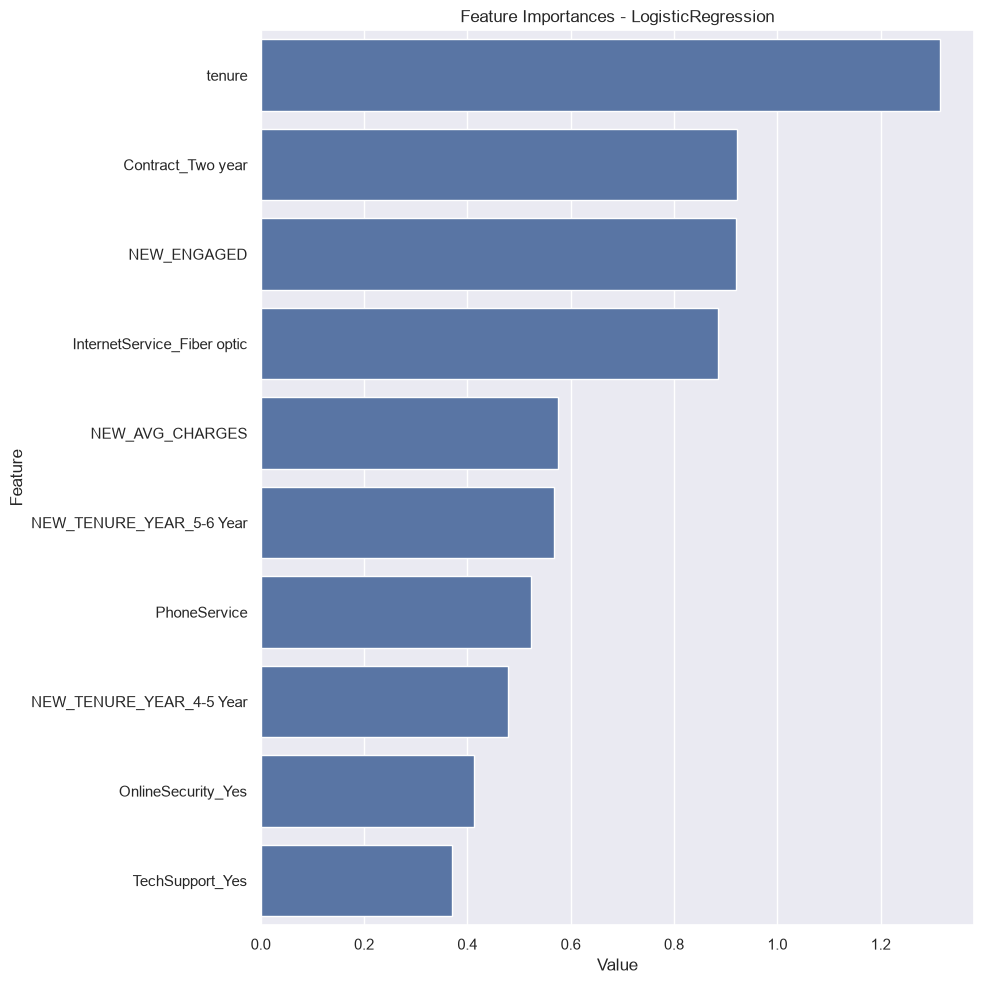

In [ ]:
def plot_importance(model, features, num=10, save=False):
    """
    Bir modelin, bağımsız değişkenlere (feature) ne kadar önem verdiğini gösteren bir
    çubuk grafik (bar plot) çizer. Ağaç tabanlı modellerde (RF, GBM, LightGBM, XGBoost, CART)
    "feature_importances_" özelliğini, doğrusal modellerde (Logistic Regression gibi) ise
    katsayıların (coefficients) mutlak değerini "önem" ölçüsü olarak kullanır.

    Parametreler
    ----------
    model : eğitilmiş (fit edilmiş) sklearn modeli.
    features : pd.DataFrame
        Modelin eğitildiği bağımsız değişkenler (sütun isimleri için kullanılır).
    num : int, opsiyonel
        Grafikte gösterilecek en önemli değişken sayısı. Varsayılan: 10.
    save : bool, opsiyonel
        True verilirse grafiği "importances.png" olarak kaydeder.
    """
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_
    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_[0])
    else:
        print(f"{type(model).__name__} için 'importance' bilgisi bulunamadı.")
        return

    feature_imp = pd.DataFrame({"Value": importance, "Feature": features.columns})
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature",
                data=feature_imp.sort_values(by="Value", ascending=False)[0:num])
    plt.title(f"Feature Importances - {type(model).__name__}")
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig("importances.png")


# Nihai (final) en başarılı modeli seçip, önce tüm veri ile eğitiyoruz (fit),
# ardından hangi değişkenlere daha çok önem verdiğini görselleştiriyoruz.
best_model_name = final_results_df.iloc[0]["model"]
best_model = best_models[best_model_name].fit(X, y)
print("En başarılı final model:", best_model_name)

plot_importance(best_model, X)